First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -

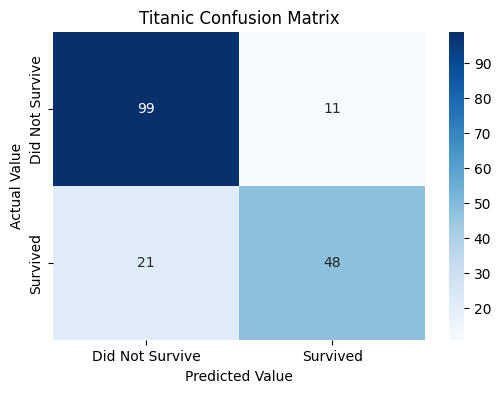

In [ ]:
# ==========================================
# TITANIC DATASET - CLASSIFICATION
# ==========================================

# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------
# Step 1: Load the Titanic dataset
# ------------------------------------------

titanic = sns.load_dataset("titanic")

# Display the first 5 rows
print("First 5 rows:")
print(titanic.head())

# Display dataset information
print("\nDataset information:")
print(titanic.info())

# ------------------------------------------
# Step 2: Select input features and target
# ------------------------------------------

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = titanic[features]

# Target variable
y = titanic["survived"]

# ------------------------------------------
# Step 3: Split the dataset
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# Step 4: Preprocess the data
# ------------------------------------------

# Numerical columns
numerical_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

# Categorical columns
categorical_features = [
    "sex",
    "embarked"
]

# Fill missing numerical values using median
numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

# Fill missing categorical values using mode
# and convert categories into numbers
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

# ------------------------------------------
# Step 5: Create the classification model
# ------------------------------------------

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

# ------------------------------------------
# Step 6: Train the model
# ------------------------------------------

model.fit(X_train, y_train)

# ------------------------------------------
# Step 7: Make predictions
# ------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------
# Step 8: Evaluate the model
# ------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# ------------------------------------------
# Step 9: Display confusion matrix
# ------------------------------------------

matrix = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(6, 4)
)

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Did Not Survive",
        "Survived"
    ],
    yticklabels=[
        "Did Not Survive",
        "Survived"
    ]
)

plt.xlabel(
    "Predicted Value"
)

plt.ylabel(
    "Actual Value"
)

plt.title(
    "Titanic Confusion Matrix"
)

plt.show()

FIRST 5 ROWS OF THE DATASET
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   Ave

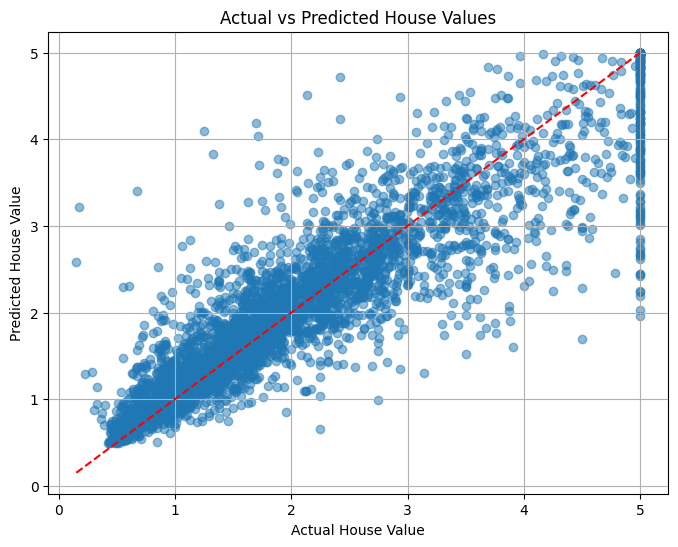


FEATURE IMPORTANCE
      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


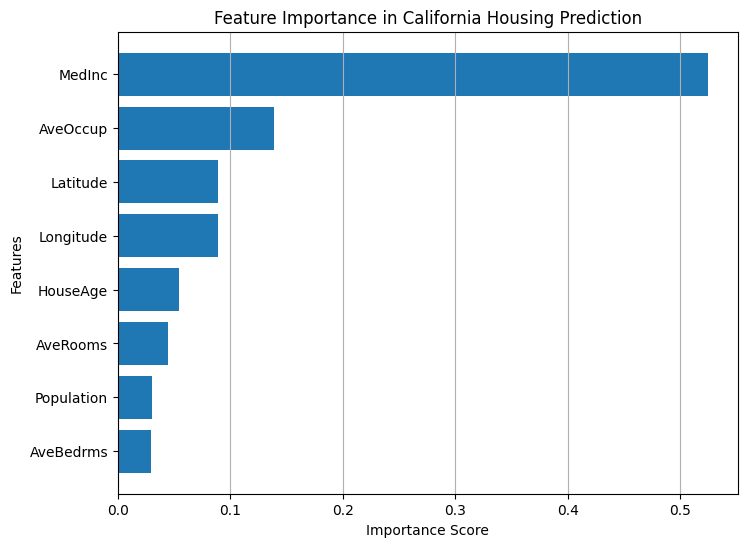

In [ ]:
# ============================================================
# CALIFORNIA HOUSING DATASET - REGRESSION TASK
# ============================================================

# ------------------------------------------------------------
# STEP 1: Import Required Libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# STEP 2: Load the California Housing Dataset
# ------------------------------------------------------------

california_data = fetch_california_housing(
    as_frame=True
)

# Convert the dataset into a Pandas DataFrame
housing = california_data.frame


# ------------------------------------------------------------
# STEP 3: Display the Dataset
# ------------------------------------------------------------

print("FIRST 5 ROWS OF THE DATASET")
print(housing.head())

print("\nDATASET INFORMATION")
print(housing.info())

print("\nDATASET SHAPE")
print(housing.shape)

print("\nMISSING VALUES")
print(housing.isnull().sum())

print("\nSTATISTICAL SUMMARY")
print(housing.describe())


# ------------------------------------------------------------
# STEP 4: Separate Input Features and Target Variable
# ------------------------------------------------------------

# Input features
X = housing.drop(
    columns=["MedHouseVal"]
)

# Target variable
y = housing["MedHouseVal"]


# ------------------------------------------------------------
# STEP 5: Split the Dataset
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Display the sizes of the datasets

print("\nTRAINING DATA SHAPE")
print(X_train.shape)

print("\nTESTING DATA SHAPE")
print(X_test.shape)


# ------------------------------------------------------------
# STEP 6: Create the Regression Model
# ------------------------------------------------------------

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# STEP 7: Train the Model
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train
)

print("\nMODEL TRAINING COMPLETED SUCCESSFULLY")


# ------------------------------------------------------------
# STEP 8: Make Predictions
# ------------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ------------------------------------------------------------
# STEP 9: Display Actual and Predicted Values
# ------------------------------------------------------------

results = pd.DataFrame(
    {
        "Actual House Value": y_test.values,
        "Predicted House Value": y_pred
    }
)

print("\nACTUAL VS PREDICTED VALUES")

print(
    results.head(10)
)


# ------------------------------------------------------------
# STEP 10: Calculate Evaluation Metrics
# ------------------------------------------------------------

# Mean Absolute Error
mae = mean_absolute_error(
    y_test,
    y_pred
)

# Mean Squared Error
mse = mean_squared_error(
    y_test,
    y_pred
)

# Root Mean Squared Error
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

# R-squared Score
r2 = r2_score(
    y_test,
    y_pred
)


# ------------------------------------------------------------
# STEP 11: Display Model Performance
# ------------------------------------------------------------

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print(
    "Mean Absolute Error (MAE):",
    round(mae, 4)
)

print(
    "Mean Squared Error (MSE):",
    round(mse, 4)
)

print(
    "Root Mean Squared Error (RMSE):",
    round(rmse, 4)
)

print(
    "R-squared Score (R²):",
    round(r2, 4)
)


# ------------------------------------------------------------
# STEP 12: Plot Actual vs Predicted Values
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

# Create a reference line
minimum_value = min(
    y_test.min(),
    y_pred.min()
)

maximum_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    "r--"
)

plt.xlabel(
    "Actual House Value"
)

plt.ylabel(
    "Predicted House Value"
)

plt.title(
    "Actual vs Predicted House Values"
)

plt.grid()

plt.show()


# ------------------------------------------------------------
# STEP 13: Feature Importance
# ------------------------------------------------------------

feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }
)

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFEATURE IMPORTANCE")

print(
    feature_importance
)


# ------------------------------------------------------------
# STEP 14: Plot Feature Importance
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.title(
    "Feature Importance in California Housing Prediction"
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x"
)

plt.show()


# ============================================================
# END OF PROGRAM
# ============================================================